Practical 1: Implement the brute force algorithm for the Vertex Cover problem for n= 10, m= 10,15,.....45. Record the vertex cover along with its size and the running time for each (n,m) pair.  Display the graph and the vertex cover formation visually.Record the ouptput of P1 in a table in addition to the graphic display

In [ ]:
import random
import time
import networkx as nx
import matplotlib.pyplot as plt
import csv

In [ ]:
def vertex_cover(vertex, cover):
    global min_cover

    if vertex > vertices:
        for start, end in edge1:
            if start not in cover and end not in cover:
                return

        if not min_cover or len(cover) < len(min_cover):
            min_cover = cover.copy()
        return

    vertex_cover(vertex + 1, cover + [vertex])
    vertex_cover(vertex + 1, cover)


Vertices : 10
Edges : 10
Minimum Vertex Cover : [1, 6, 7, 9]
Cover Size : 4
Running Time : 0.0013287067413330078


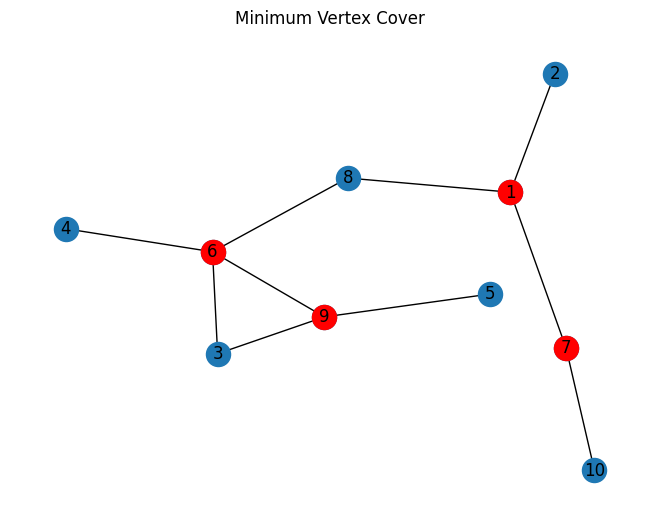


Vertices : 10
Edges : 15
Minimum Vertex Cover : [1, 2, 5, 6, 10]
Cover Size : 5
Running Time : 0.001367807388305664


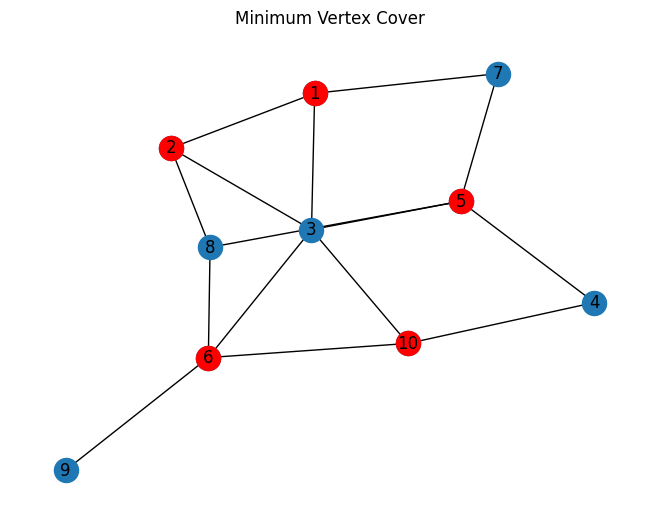


Vertices : 10
Edges : 20
Minimum Vertex Cover : [1, 2, 3, 4, 5, 6]
Cover Size : 6
Running Time : 0.0015201568603515625


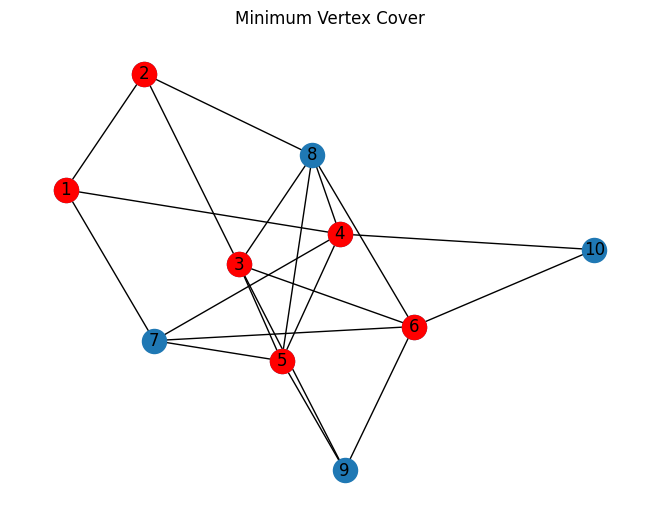


Vertices : 10
Edges : 25
Minimum Vertex Cover : [1, 2, 4, 6, 7, 8, 9]
Cover Size : 7
Running Time : 0.0015823841094970703


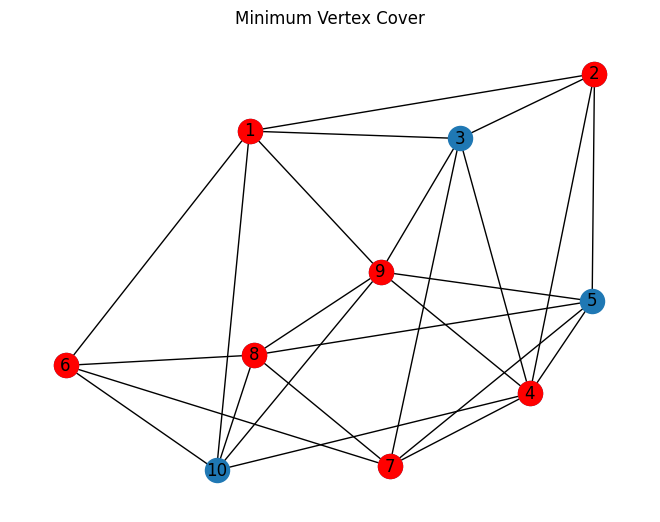


Vertices : 10
Edges : 30
Minimum Vertex Cover : [1, 2, 5, 7, 8, 9, 10]
Cover Size : 7
Running Time : 0.0016376972198486328


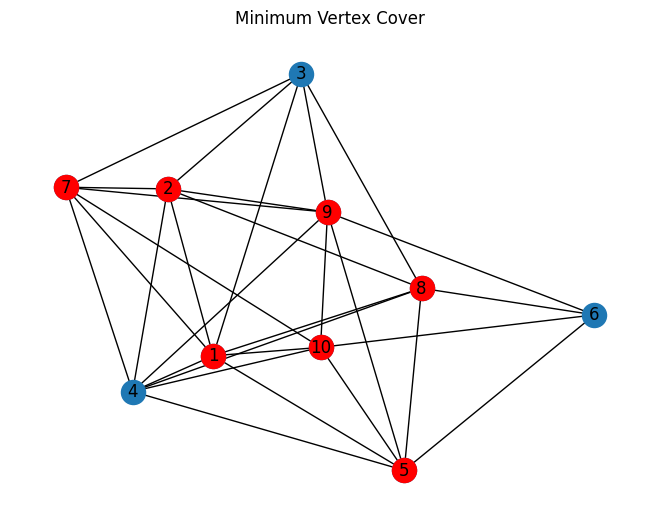


Vertices : 10
Edges : 35
Minimum Vertex Cover : [1, 4, 6, 7, 8, 9, 10]
Cover Size : 7
Running Time : 0.0016815662384033203


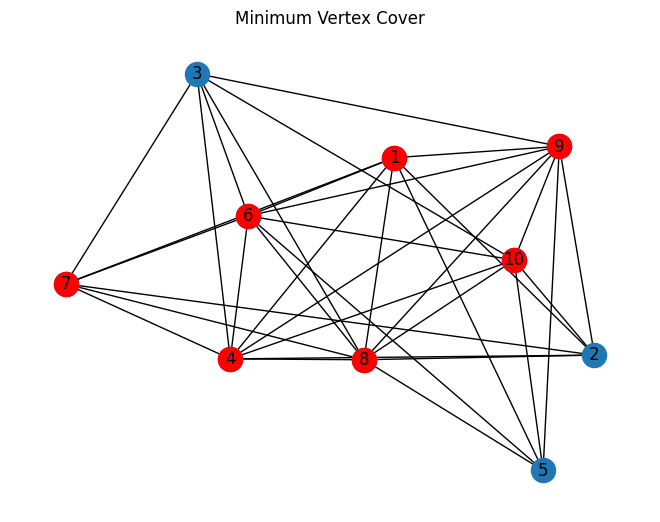


Vertices : 10
Edges : 40
Minimum Vertex Cover : [1, 2, 3, 4, 5, 6, 8, 10]
Cover Size : 8
Running Time : 0.0013818740844726562


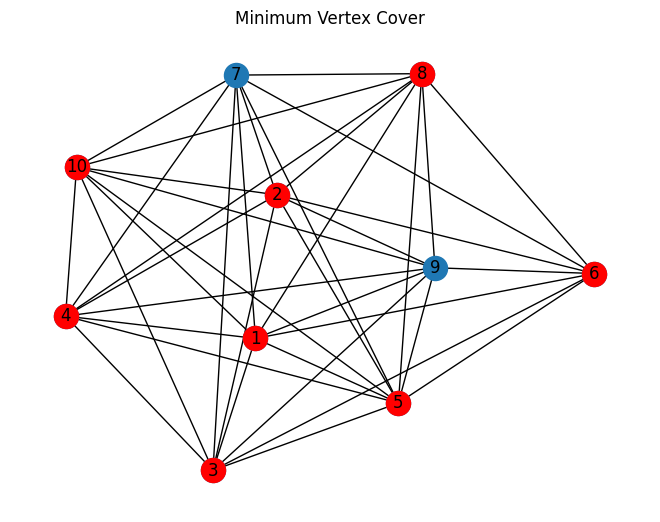


Vertices : 10
Edges : 45
Minimum Vertex Cover : [1, 2, 3, 4, 5, 6, 7, 8, 9]
Cover Size : 9
Running Time : 0.0017428398132324219


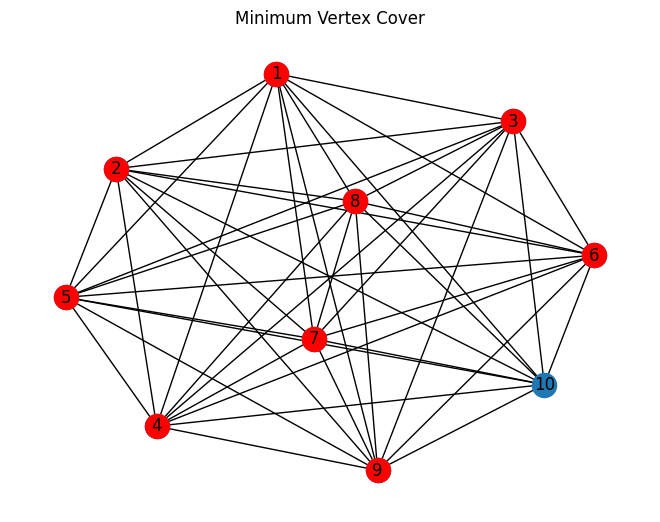

In [ ]:
vertices = 10
results = []

for edges in range(10, 46, 5):
    edge1 = []

    while len(edge1) < edges:
        start = random.randint(1, vertices)
        end = random.randint(1, vertices)

        if start != end and [start, end] not in edge1 and [end, start] not in edge1:
            edge1.append([start, end])

    file_name="file_vc"+str(edges) +".txt"

    with open(file_name, "w") as file:
        for start, end in edge1:
            file.write(str(start) + "," + str(end) + "\n")

    graph = nx.Graph()

    with open(file_name, "r") as file:
        for line in file:
            start, end = line.strip().split(",")
            graph.add_edge(int(start), int(end))

    graph.add_nodes_from(range(1, vertices + 1))

    min_cover = []

    start_time = time.time()

    vertex_cover(1, min_cover)

    end_time = time.time()

    print("\nVertices :", vertices)
    print("Edges :", edges)
    print("Minimum Vertex Cover :", min_cover)
    print("Cover Size :", len(min_cover))
    print("Running Time :", end_time - start_time)

    results.append(["(" + str(vertices) + ", " + str(edges) + ")",len(min_cover),end_time - start_time])

    pos = nx.spring_layout(graph)

    nx.draw(graph, pos, with_labels=True)

    nx.draw_networkx_nodes(graph,pos,nodelist = min_cover,node_color="red")

    plt.title("Minimum Vertex Cover")
    plt.savefig("graph_" + str(edges) + "_edges.png")
    plt.show()
    plt.close()

In [ ]:
with open("vertex_cover_results.csv", "w", newline="") as csvfile:

    writer = csv.writer(csvfile)
    writer.writerow(["(n, m)","BF Size"," BF Time"])
    writer.writerows(results)

print("All results saved to vertex_cover_results.csv")

All results saved to vertex_cover_results.csv
